# Individual Fin Model

Author  
Mateus Stano Junqueira

Date  
March 2025

## Introduction

There are currently three ways to model the aerodynamic effects of fins
in RocketPy:

1.  By use of the `rocketpy.GenericSurface` or
    `rocketpy.LinearGenericSurface` classes, which are defined by
    receiving the aerodynamic coefficients directly;
2.  By use of the `rocketpy.Fins` classes (`rocketpy.TrapezoidalFins`,
    `rocketpy.EllipticalFins`, `rocketpy.FreeFormFins`), which are
    defined by receiving the geometric parameters of the **fin set** and
    calculating the aerodynamic coefficients internally with the
    Barrowman method;
3.  By use of the `rocketpy.Fin` classes (`rocketpy.TrapezoidalFin`,
    `rocketpy.EllipticalFin`, `rocketpy.FreeFormFin`) (which are the
    base classes for the fin set classes), which are defined by
    receiving the geometric parameters of **one single fin** and
    calculating the aerodynamic coefficients internally with the
    Barrowman method, with exception of the moment coefficients, which
    have been derived in this document.

This document will focus on all the mathematical derivations and
implementations of the `rocketpy.Fin` classes.

## Fin Coordinate Frame

The fin coordinate frame is defined as follows:

-   The origin is at the leading edge of the fin, at the intersection of
    the fin's root chord and the fin's leading edge;
-   The z-axis is aligned with the fin's root chord, pointing towards
    the fin's trailing edge;
-   The y-axis is aligned with the fin's span, pointing towards the
    fin's tip chord;
-   The x-axis completes the right-handed coordinate system.

The fin is postioned at the rocket's body, given a `rocket_radius` $r$,
an `angular_position` $\Gamma$ and a position $p$ along the rocket's
body. The angular position is given according to
`Angular Position Inputs <angular_position>`.

The fin can also be rotated by a cant angle $\delta$.

The image below shows the fin coordinate frame:

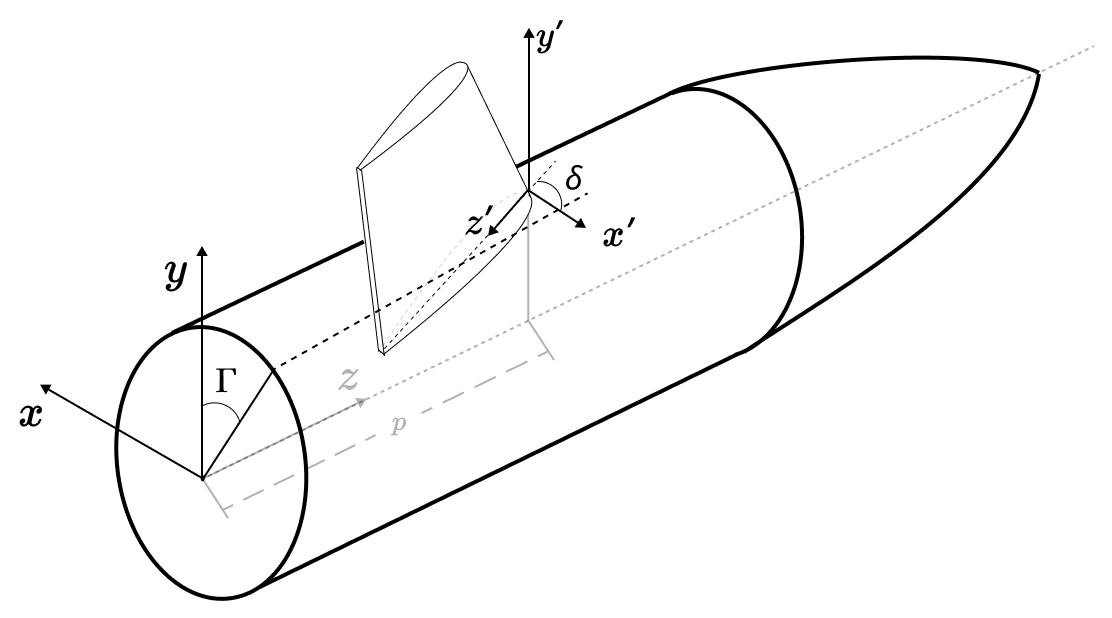

Note

A positive cant angle $\delta$ produces a negative body axis rolling
moment at zero angle of attack.

The rotation matrix from the fin coordinate frame to the rocket's body
frame is define by, first a rotation around the y-axis by 180 degrees:

$$\begin{aligned}
\mathbf{R}_{y(\pi)} = \begin{bmatrix}
-1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & -1
\end{bmatrix}
\end{aligned}$$

Then a rotation around the z-axis by the angle $\Gamma$:

$$\begin{aligned}
\mathbf{R}_{z(\Gamma)} = \begin{bmatrix}
\cos(\Gamma) & -\sin(\Gamma) & 0 \\
\sin(\Gamma) & \cos(\Gamma) & 0 \\
0 & 0 & 1
\end{bmatrix}
\end{aligned}$$

Then a rotation around the y-axis by the cant angle $\delta$:

$$\begin{aligned}
\mathbf{R}_{y(\delta)} = \begin{bmatrix}
\cos(\delta) & 0 & \sin(\delta) \\
0 & 1 & 0 \\
-\sin(\delta) & 0 & \cos(\delta)
\end{bmatrix}
\end{aligned}$$

The final rotation matrix is given by:

$$\mathbf{R} = \mathbf{R}_{y(\delta)} \cdot \mathbf{R}_{z(\Gamma)} \cdot \mathbf{R}_{y(\pi)}$$

The position of the fin's coordinate frame origin in the rocket's body
frame is calculated by first assuming no a fin frame with no cant angle,
then calculating the position of the fin's leading edge (with cant
angle) in this frame, and finally translating this position to the fin's
position in the rocket's body frame. The position of the fin's real
leading edge in this no cant angle fin frame is given by the point
$\mathbf{P}^{\delta}_{le_f}$:

$$\begin{aligned}
\mathbf{P}^{\delta}_{le_f} = \begin{bmatrix}
-\frac{Cr}{2} \sin(\delta) \\
0 \\
\frac{Cr}{2} (1 - \cos(\delta))
\end{bmatrix}
\end{aligned}$$

Then, describing this point to the rocket's body frame orientation (no
translation):

$$\mathbf{P}^{\delta}_{le_b} = (\mathbf{R}_{z(\Gamma)} \cdot \mathbf{R}_{y(\pi)}) \cdot \mathbf{P}^{\delta}_{le_f}$$

The position of the fin's leading edge with no cant angle in the
rocket's body frame is given by:

$$\begin{aligned}
\mathbf{P}^{\overline{\delta}}_{le_b} = \begin{bmatrix}
-r \sin(\Gamma) \\
r \cos(\Gamma) \\
p
\end{bmatrix}
\end{aligned}$$

Finally, we add the position of the fin's leading edge with no cant
angle to the position of the fin's leading edge with cant angle in the
rocket's body frame:

$$\mathbf{P}_{le_b} = \mathbf{P}^{\overline{\delta}}_{le_b} + \mathbf{P}^{\delta}_{le_b}$$

## Center of Pressure Position

In the Fin Coordinate Frame, the center of pressure is given by the
Barrowman method, and will here only be defined symbolically:

$$\begin{aligned}
\mathbf{cp}_f = \begin{bmatrix}
cp_x \\
cp_y \\
cp_z
\end{bmatrix}
\end{aligned}$$

The center of pressure position in the rocket's body frame is given by:

$$\mathbf{cp}_{rocket} = \mathbf{R} \cdot \mathbf{cp}_f + \mathbf{P}_{le_b}$$

## Aerodynamic Forces

Note

The aerodynamic coefficients are defined according the Barrowman method.

Given a stream velocity in the fin frame
$\mathbf{v}_{0f} = [v_{0x}, v_{0y}, v_{0z}]^{T}$, the effective angle of
attack of the fin is given by:

$$\alpha_f = \arctan\left(\frac{v_{0x}}{v_{0z}}\right)$$

This can also be seen as the angle between the fin's root chord and the
stream velocity vector in the fin frame.

The aerodynamic force in the x-direction of the fin is given by:

$$F_{x} = \frac{1}{2} \cdot \rho \cdot \|\mathbf{v}_{0f}\|^2 \cdot A_{r} \cdot C_{N}(\alpha_f, Ma)$$

Where $A_{r}$ is the reference area of the fin, and $C_{N}$ is the
normal force coefficient, which is a function of the angle of attack and
the Mach number $Ma$. This force is then transformed to the rocket's
body frame by the rotation matrix:

$$\begin{aligned}
\begin{bmatrix}
F_{x} \\
F_{y} \\
F_{z}
\end{bmatrix}_{rocket} = \mathbf{R} \cdot \begin{bmatrix}
F_{x} \\
0 \\
0
\end{bmatrix}_{fin}
\end{aligned}$$

Then, the moments are calculated by the cross product of the center of
pressure and the aerodynamic force:

$$\begin{aligned}
\begin{bmatrix}
M_{x} \\
M_{y} \\
M_{z}
\end{bmatrix}_{rocket} = \mathbf{cp}_{rocket} \times \begin{bmatrix}
F_{x} \\
F_{y} \\
F_{z}
\end{bmatrix}_{rocket}
\end{aligned}$$

From the Barrowman method, the moment along the center axis of the
rocket ($M_{z}$) is still missing the damping term, which is given by:

$$M_{damp} = \frac{1}{2} \cdot \rho \cdot \|v_{0}\| \cdot A_{r} \cdot L_{r}^2 \cdot C_{ld\omega}(Ma) \cdot \frac{1}{2} \cdot \omega_z$$

$$M_{z \, \text{final}} = M_{z} + M_{damp}$$

Where $C_{ld}$ is the roll moment damping coefficient, $L_{r}$ is the
reference length, which is equal to the rocket diameter, and $\omega_z$
is the angular velocity of the rocket around the z-axis.

## Adding Individual Fins to the Rocket

from rocketpy import \* env = Environment(latitude=32.990254,
longitude=-106.974998, elevation=1400) Pro75M1670 = SolidMotor(
thrust_source="../data/motors/cesaroni/Cesaroni_M1670.eng",
dry_mass=1.815, dry_inertia=(0.125, 0.125, 0.002), nozzle_radius=33 /
1000, grain_number=5, grain_density=1815, grain_outer_radius=33 / 1000,
grain_initial_inner_radius=15 / 1000, grain_initial_height=120 / 1000,
grain_separation=5 / 1000, grains_center_of_mass_position=0.397,
center_of_dry_mass_position=0.317, nozzle_position=0, burn_time=3.9,
throat_radius=11 / 1000,
coordinate_system_orientation="nozzle_to_combustion_chamber", ) \#
IMPORTANT: modify the file paths below to match your own system

example_rocket = Rocket(  
radius=127 / 2000, mass=14.426, inertia=(6.321, 6.321, 0.034),
power_off_drag="../data/rockets/calisto/powerOffDragCurve.csv",
power_on_drag="../data/rockets/calisto/powerOnDragCurve.csv",
center_of_mass_without_motor=0,
coordinate_system_orientation="tail_to_nose",

)

rail_buttons = example_rocket.set_rail_buttons(  
upper_button_position=0.0818, lower_button_position=-0.618,
angular_position=45,

) example_rocket.add_motor(Pro75M1670, position=-1.255) nose_cone =
example_rocket.add_nose(length=0.55829, kind="vonKarman",
position=1.278) tail = example_rocket.add_tail( top_radius=0.0635,
bottom_radius=0.0435, length=0.060, position=-1.194656 )
example_rocket.add_trapezoidal_fins( n=4, root_chord=0.120,
tip_chord=0.060, span=0.110, cant_angle=0.0, position=-1.04956,
airfoil=("../data/airfoils/NACA0012-radians.txt", "radians"), )

Given a defined `Rocket` object, we can add individual fins to the
rocket by using the `add_surfaces` method. Here is an example of adding
two canards in the Calisto rocket from the
`First Simulation <firstsimulation>` example:

canard1 = TrapezoidalFin(  
angular_position=0, root_chord=0.060, tip_chord=0.020, span=0.03,
rocket_radius=example_rocket.radius, cant_angle=0.5,
airfoil=("../data/airfoils/NACA0012-radians.txt", "radians"),

) canard2 = TrapezoidalFin( angular_position=180, root_chord=0.060,
tip_chord=0.020, span=0.03, rocket_radius=example_rocket.radius,
cant_angle=0.5, airfoil=("../data/airfoils/NACA0012-radians.txt",
"radians"), )

\# Position along the center axis of the rocket is specified here. \# If
different positions are desired, the position can be specified as a
list. example_rocket.add_surfaces(\[canard1, canard2\], positions =
0.35)

example_rocket.draw(plane="yz")

There are three classes for defining fins in RocketPy given their
geometry:

-   `rocketpy.TrapezoidalFin` - For how to define a trapezoidal fin
-   `rocketpy.EllipticalFin` - For how to define an elliptical fin
-   `rocketpy.FreeFormFin` - For how to define a free form fin

## Fin Force Conventions

Here we exemplify the fin force conventions relating the cant angle
(deflection angle) of the fins to the pitch, yaw and roll moments. We
will consider a rocket with four fins, to illustrate the concepts. The
image below show the sign convention for the forces acting on the fins,
given positive cant angles:

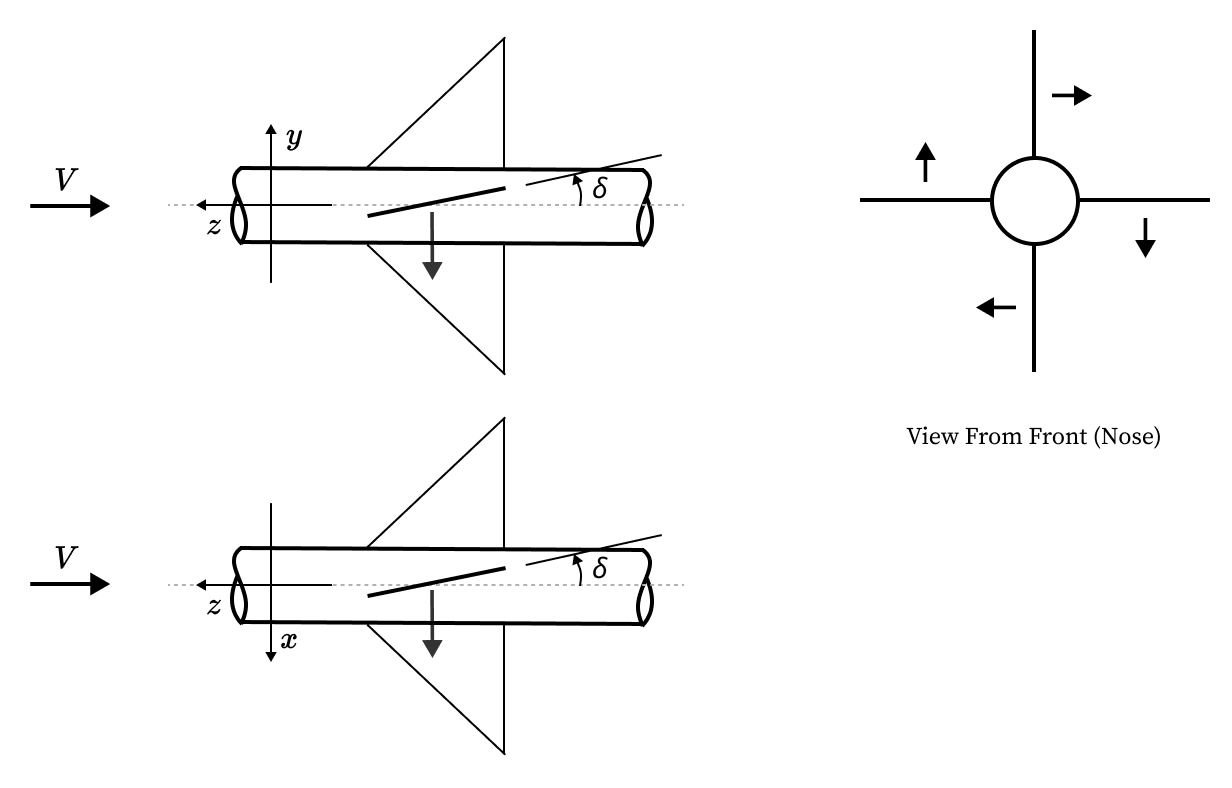

### Roll

example_rocket.aerodynamic_surfaces.pop()
example_rocket.aerodynamic_surfaces.pop()

A positive cant angle $\delta$ produces a negative roll moment at zero
angle of attack. Any fin with a positive cant angle will produce a
negative roll moment, and any fin with a negative cant angle will
produce a positive roll moment.

Here is a flight of the calisto with canards defined with a positive
cant angle:

canard1 = TrapezoidalFin(  
angular_position=0, root_chord=0.060, tip_chord=0.020, span=0.03,
rocket_radius=example_rocket.radius, cant_angle=0.5,
airfoil=("../data/airfoils/NACA0012-radians.txt", "radians"),

) canard2 = TrapezoidalFin( angular_position=180, root_chord=0.060,
tip_chord=0.020, span=0.03, rocket_radius=example_rocket.radius,
cant_angle=0.5, airfoil=("../data/airfoils/NACA0012-radians.txt",
"radians"), )

example_rocket.add_surfaces(\[canard1, canard2\], positions = 0.35)

test_flight = Flight(  
rocket=example_rocket, environment=env, rail_length=5.2, inclination=85,
heading=0, terminate_on_apogee=True,

)

\# Rolling Moment test_flight.M3()

\# Rolling Speed test_flight.w3()

\# Angle of attack
test_flight.partial_angle_of_attack.plot(test_flight.out_of_rail_time,
5)

\# Angle of sideslip
test_flight.angle_of_sideslip.plot(test_flight.out_of_rail_time, 5)

### Pitch

example_rocket.aerodynamic_surfaces.pop()
example_rocket.aerodynamic_surfaces.pop()

Given canards fins at 90 degrees and 270 degrees, having opposite cant
angles, a positive pitch moment will be generated. The following example
shows the effect of this configuration in the non-zero angle of attack
flight of the rocket:

canard1 = TrapezoidalFin(  
angular_position=90, root_chord=0.060, tip_chord=0.020, span=0.03,
rocket_radius=example_rocket.radius, cant_angle=0.5,
airfoil=("../data/airfoils/NACA0012-radians.txt", "radians"),

) canard2 = TrapezoidalFin( angular_position=270, root_chord=0.060,
tip_chord=0.020, span=0.03, rocket_radius=example_rocket.radius,
cant_angle=-0.5, airfoil=("../data/airfoils/NACA0012-radians.txt",
"radians"), )

example_rocket.add_surfaces(\[canard1, canard2\], positions = 0.35)

test_flight = Flight(  
rocket=example_rocket, environment=env, rail_length=5.2, inclination=85,
heading=0, terminate_on_apogee=True,

)

\# Angle of attack
test_flight.partial_angle_of_attack.plot(test_flight.out_of_rail_time,
5)

\# Angle of sideslip
test_flight.angle_of_sideslip.plot(test_flight.out_of_rail_time, 5)

### Yaw

example_rocket.aerodynamic_surfaces.pop()
example_rocket.aerodynamic_surfaces.pop()

Given opposing canards at 0 degrees and 180 degrees, having opposite
cant angles, a positive yaw moment will be generated. The following
example shows the effect of this configuration in the non-zero angle of
attack flight of the rocket:

canard1 = TrapezoidalFin(  
angular_position=0, root_chord=0.060, tip_chord=0.020, span=0.03,
rocket_radius=example_rocket.radius, cant_angle=0.5,
airfoil=("../data/airfoils/NACA0012-radians.txt", "radians"),

) canard2 = TrapezoidalFin( angular_position=180, root_chord=0.060,
tip_chord=0.020, span=0.03, rocket_radius=example_rocket.radius,
cant_angle=-0.5, airfoil=("../data/airfoils/NACA0012-radians.txt",
"radians"), )

example_rocket.add_surfaces(\[canard1, canard2\], positions = 0.35)

test_flight = Flight(  
rocket=example_rocket, environment=env, rail_length=5.2, inclination=85,
heading=0, terminate_on_apogee=True,

)

\# Angle of attack
test_flight.partial_angle_of_attack.plot(test_flight.out_of_rail_time,
5)

\# Angle of sideslip
test_flight.angle_of_sideslip.plot(test_flight.out_of_rail_time, 5)